# Bulgarian Day-Ahead Market — 48 h price forecast (model)

Nine years of BG day-ahead prices, the day-ahead load / wind / solar forecasts, Sofia weather,
neighbour prices and fuel closes, fed to **LightGBM** and scored against the benchmark set in
[01_exploration.ipynb](01_exploration.ipynb): *same hour last week*, MAE 29 EUR/MWh.

## Prepare the environment

### Install the libraries

Implementing the install_if_not_installed function for reader simplicity

In [1]:
%%capture
import importlib
import subprocess
import sys


def install_if_not_installed(package, module=None):
    try:
        importlib.import_module(module or package.replace("-", "_"))
        print(f"{package} is already installed.")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


# List of packages to install  (PyPI name, import name where they differ)
packages = [
    ("pandas", None),
    ("numpy", None),
    ("pyarrow", None),
    ("plotly", None),
    ("scikit-learn", "sklearn"),
    ("lightgbm", None),
    ("holidays", None),
    ("joblib", None),
    ("entsoe-py", "entsoe"),
    ("yfinance", None),
    ("python-dotenv", "dotenv"),
]

for package, module in packages:
    install_if_not_installed(package, module)

### Import the libraries

The feature code and the model live in [`dam_forecast/`](../dam_forecast) and are imported here,
so this notebook evaluates exactly what [`forecast.py`](../forecast.py) runs.

In [2]:
import calendar
import inspect
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Code
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "..")                      # the repo root, where dam_forecast/ lives
from dam_forecast import config, features, model, sources

pio.templates.default = "plotly_white"
try:                                          # a static PNG copy too, so figures show on GitHub
    pio.to_image(go.Figure(), format="png")
    pio.renderers.default = "notebook_connected+png"
    pio.renderers["png"].width, pio.renderers["png"].scale = 1100, 1
except Exception:
    pio.renderers.default = "notebook_connected"

SEQ = "Viridis"   # magnitude
DIV = "RdBu"      # signed, centred on zero
MONTH_ORDER = list(range(1, 13))
FIG_DIR = Path("../docs/figures")             # the README embeds these PNGs


def save(fig, name):
    """Write a PNG copy of a figure for the README; skipped quietly without Kaleido."""
    try:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.write_image(FIG_DIR / f"{name}.png", width=1100, scale=1)
    except Exception:
        pass

### Settings — the only cell you need to edit
`REFRESH = True` re-downloads 2017 → today (needs an ENTSO-E key in `../.env`, ~5 min).
`RUN_LSTM = True` runs the optional LSTM comparison (needs `requirements-lstm.txt`, ~5 min on CPU).

In [3]:
REFRESH  = False
RUN_LSTM = True

## Read and check data

2017-01-01 -> 2026-09-21   85,223 hours, 15 columns, uniform hourly grid


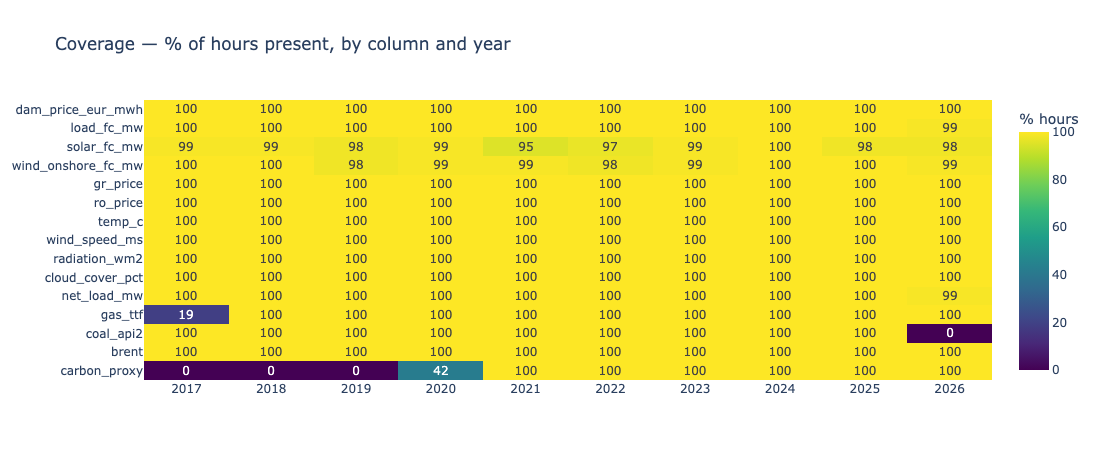

In [4]:
df = sources.build_dataset() if REFRESH else sources.load_dataset()

assert df.index.tz is not None and not df.index.has_duplicates and df.index.is_monotonic_increasing
assert (df.index.to_series().diff().dropna() == pd.Timedelta("1h")).all(), "not a uniform hourly grid"

print(f"{df.index.min():%Y-%m-%d} -> {df.index.max():%Y-%m-%d}   {len(df):,} hours, "
      f"{df.shape[1]} columns, uniform hourly grid")

# Coverage: share of hours present, per column and year — sampled yearly, so the figure stays small.
cover = (df.notna().groupby(df.index.year).mean() * 100).T.round(0)
fig = go.Figure(go.Heatmap(z=cover, x=[str(y) for y in cover.columns], y=cover.index, colorscale=SEQ,
                           zmin=0, zmax=100, colorbar=dict(title="% hours"),
                           text=cover.astype(int).astype(str), texttemplate="%{text}",
                           hovertemplate="%{y} %{x} — %{z}%<extra></extra>"))
fig.update_layout(height=460, title="Coverage — % of hours present, by column and year",
                  yaxis=dict(autorange="reversed"))
fig.show()
save(fig, "model_1_coverage")

| Source | Columns | Used as |
|---|---|---|
| ENTSO-E | BG price (target); day-ahead load, wind, solar **forecasts** | target; drivers at their own hour |
| ENTSO-E | GR, RO day-ahead prices | lags ≥ 48 h |
| Open-Meteo | Sofia temperature, wind, radiation, cloud | at their own hour |
| Yahoo Finance | TTF gas, API2 coal, Brent, KRBN carbon proxy | gas as lags ≥ 48 h |

### Understanding the data

1. **Complete where it matters**: price, weather and neighbour prices cover 100 % of 2017–2026; the ENTSO-E driver forecasts miss 1–5 % of hours in some years.
2. **Fuels are patchy**: TTF gas starts Oct 2017 and the KRBN carbon proxy mid-2020; Yahoo's API2 coal stops in Dec 2025, so coal is **dropped** — a live forecast could never have it.
3. **Settlement change**: 15-minute prices from 1 Oct 2025 are averaged to hourly, so a 48-row lag always means 48 hours.

## Features

**The leakage rule.** The forecast is made at 08:00 for up to 48 h ahead, so a feature may only use what is
published by then: day-ahead forecasts and weather at their own hour, anything price-derived only as a
**lag of ≥ 48 h** (rolling windows are shifted 48 h before they roll). Source:
[`dam_forecast/features.py`](../dam_forecast/features.py) — shown below straight from the file.

In [5]:
Code(inspect.getsource(features.make_features), language="python")

def make_features(df):
    """Turn the raw hourly table (price target + day-ahead inputs) into a
    model-ready feature matrix — a SUPERSET of candidate columns. Which columns
    each model actually uses is decided next cell (trees vs. linear/LSTM want
    different encodings), but every column here obeys one hard rule:

    THE LEAKAGE RULE — a feature may only use information known at 08:00, the
    moment the 48 h-ahead forecast is made.
      • Day-ahead FORECASTS (load, wind, solar) and weather forecasts are
        published before the auction, so they are fair game at their own
        timestamp — that is the whole reason we collected forecasts, not actuals.
      • Past PRICES arrive with a delay. For a 48 h horizon, the newest price we
        can safely rely on for EVERY target hour in the window is 48 h old — so
        price-derived features start at 48 h and never at 24 h.
    One pure function means training and live inference share code and can never
    silently diverge.
    """
    out = df.copy()
    idx = out.index

    # ── Calendar features (always known in advance → free and safe) ─────────
    # Two encodings on purpose: the RAW integers below are for the TREES (they
    # split on them directly); the sin/cos pairs further down are for the LINEAR
    # / LSTM models, which need smooth cyclical inputs rather than magnitudes.
    out["hour"]       = idx.hour
    out["dayofweek"]  = idx.dayofweek                 # 0 = Monday
    out["month"]      = idx.month
    out["is_weekend"] = (idx.dayofweek >= 5).astype(int)

    # Bulgarian public holidays depress industrial demand and behave like
    # Sundays, whatever weekday they land on.
    bg_holidays = holidays_lib.Bulgaria(years=range(idx.year.min(), idx.year.max() + 1))
    out["is_holiday"] = idx.to_series().dt.date.apply(lambda d: d in bg_holidays).astype(int).values

    # Cyclical encoding: as raw integers, hour 23 and hour 0 look far apart even
    # though they are adjacent in time. sin/cos pairs restore that adjacency —
    # essential for the linear baseline and the LSTM (trees ignore them, so we
    # feed the raw integers to the trees and the sin/cos to the linear models).
    out["hour_sin"]  = np.sin(2 * np.pi * out["hour"]  / 24)
    out["hour_cos"]  = np.cos(2 * np.pi * out["hour"]  / 24)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    # ── Lagged price features (leakage-safe: every lag ≥ 48 h) ──────────────
    # "What was the price at this hour 2 days / 3 days / a week ago?" The 168 h
    # (7-day) lag carries the weekly shape; 48 h / 72 h carry the most recent
    # level we are allowed to see.
    price = out["dam_price_eur_mwh"]
    out["price_lag_48h"]  = price.shift(48)
    out["price_lag_72h"]  = price.shift(72)
    out["price_lag_168h"] = price.shift(168)

    # Rolling statistics over windows ENDING 48 h before the target hour. The
    # .shift(48) BEFORE .rolling() keeps the window from peeking at anything
    # newer than 48 h — the same leakage rule as the lags.
    past = price.shift(48)
    out["price_roll_mean_7d"]  = past.rolling(168).mean()   # kept only to build the trend below
    out["price_roll_std_7d"]   = past.rolling(168).std()    # recent VOLATILITY (spike context)
    # A 30-day mean is a far steadier "regime level" than a single week — a hot
    # week in July says little about the price regime, a month says a lot. The
    # 7d-minus-30d spread is an explicit up/down TREND signal, and because it is
    # a DIFFERENCE it stays in-range for trees even as the market drifts (trees
    # can't extrapolate a rising level, but they can read "trend is positive").
    # price_roll_mean_30d also doubles as the BASELINE the models detrend against.
    out["price_roll_mean_30d"] = past.rolling(720).mean()   # ~30d level / regime
    out["price_trend_7d_30d"]  = out["price_roll_mean_7d"] - out["price_roll_mean_30d"]

    # ── Demand-ramp features (

In [6]:
feat = features.make_features(df)
sets = features.feature_sets(feat)
mdf  = features.modeling_frame(feat)
TREE, LINEAR, TARGET = sets["tree"], sets["linear"], config.TARGET

blocks = {"calendar": config.CAL_RAW, "price lags": config.PRICE_LAGS, "rolling": config.ROLLING,
          "ramps": config.RAMP, "drivers": config.DRIVERS, "weather": config.WEATHER,
          "neighbours": config.NEIGHBOUR, "fuel": config.FUEL}
for name, cols in blocks.items():
    print(f"{name:11s} {[c for c in cols if c in TREE]}")
print(f"\n{len(TREE)} features | {len(mdf):,} usable hours "
      f"({mdf.index.min():%Y-%m-%d} -> {mdf.index.max():%Y-%m-%d})")

calendar    ['hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday']
price lags  ['price_lag_48h', 'price_lag_72h', 'price_lag_168h']
rolling     ['price_roll_std_7d', 'price_roll_mean_30d', 'price_trend_7d_30d']
ramps       ['load_ramp_1h', 'net_load_ramp_1h', 'net_load_ramp_3h']
drivers     ['net_load_mw', 'load_fc_mw', 'solar_fc_mw', 'wind_onshore_fc_mw']
weather     ['temp_c', 'wind_speed_ms', 'radiation_wm2', 'cloud_cover_pct']
neighbours  ['ro_price_lag_48h', 'ro_price_lag_168h', 'gr_price_lag_48h']
fuel        ['gas_ttf_lag_48h', 'gas_ttf_chg_1w']

27 features | 82,540 usable hours (2017-02-02 -> 2026-09-21)


## Models

Chronological split — the most recent 15 % is the holdout, never shuffled. The research first detrended the
target (predict price − its 30-day level, then add it back: *residual*); both that and the plain price
(*direct*) are scored. The production model code, from [`dam_forecast/model.py`](../dam_forecast/model.py):

In [7]:
Code("\n\n".join(inspect.getsource(f) for f in (model.chrono_split, model.fit, model.predict,
                                                  model.evaluate)), language="python")

def chrono_split(model_df, test_fraction=config.TEST_FRACTION):
    cut = int(len(model_df) * (1 - test_fraction))
    return model_df.iloc[:cut], model_df.iloc[cut:]


def fit(train, features, mode=config.TARGET_MODE):
    y = train[config.TARGET] - _baseline(train, mode)
    return LGBMRegressor(**config.LGBM_PARAMS).fit(train[features], y)


def predict(model, frame, features, mode=config.TARGET_MODE):
    return model.predict(frame[features]) + _baseline(frame, mode)


def evaluate(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    smape = (2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)).mean() * 100
    return {"model": name,
            "MAE": float(np.abs(err).mean()),
            "RMSE": float(np.sqrt((err ** 2).mean())),
            "sMAPE_%": float(smape)}

In [8]:
train, test = model.chrono_split(mdf)
y = test[TARGET]
print(f"train {train.index.min():%Y-%m-%d} -> {train.index.max():%Y-%m-%d} ({len(train):,} h)   "
      f"holdout {test.index.min():%Y-%m-%d} -> {test.index.max():%Y-%m-%d} ({len(test):,} h)")

preds = {"Seasonal naive": test["price_lag_168h"].to_numpy()}

for mode in ("residual", "direct"):
    base = lambda f: f[config.BASELINE_COL].to_numpy() if mode == "residual" else 0.0
    ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0))
    ridge.fit(train[LINEAR], train[TARGET] - base(train))
    preds[f"Ridge ({mode})"] = ridge.predict(test[LINEAR]) + base(test)
    lgbm = model.fit(train, TREE, mode)
    preds[f"LightGBM ({mode})"] = model.predict(lgbm, test, TREE, mode)

lgbm = model.fit(train, TREE)                 # the production setting, config.TARGET_MODE
scores = model.scoreboard([model.evaluate(k, y, v) for k, v in preds.items()])
scores

train 2017-02-02 -> 2025-04-06 (70,159 h)   holdout 2025-04-06 -> 2026-09-21 (12,381 h)


,MAE,RMSE,sMAPE_%
model,,,
Seasonal naive,28.57,42.97,44.31
Ridge (residual),25.24,34.69,40.77
LightGBM (residual),27.20,36.57,40.05
Ridge (direct),25.24,34.69,40.77
LightGBM (direct),23.32,33.01,36.66


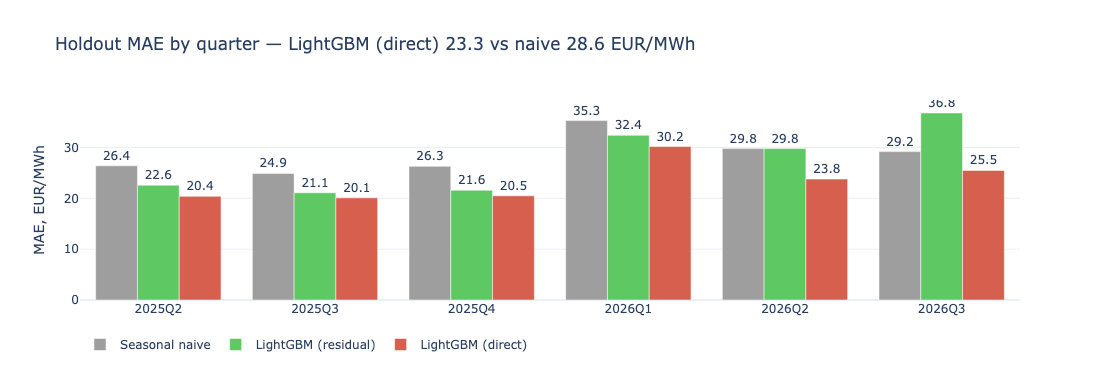

In [9]:
best = "LightGBM (direct)"
err = pd.DataFrame({k: np.abs(v - y.to_numpy()) for k, v in preds.items()}, index=test.index)
by_q = err[["Seasonal naive", "LightGBM (residual)", best]].groupby(test.index.tz_localize(None).to_period("Q")).mean()

fig = go.Figure()
for col, colour in zip(by_q.columns, ["#9e9e9e", "#5ec962", "#d6604d"]):
    fig.add_bar(x=by_q.index.astype(str), y=by_q[col].round(1), name=col, marker_color=colour,
                text=by_q[col].round(1), textposition="outside")
fig.update_layout(height=380, barmode="group", yaxis_title="MAE, EUR/MWh",
                  legend=dict(orientation="h", y=-0.15),
                  title=f"Holdout MAE by quarter — {best} {scores.loc[best, 'MAE']:.1f} "
                        f"vs naive {scores.loc['Seasonal naive', 'MAE']:.1f} EUR/MWh")
fig.show()
save(fig, "model_2_mae_by_quarter")

### Understanding the scoreboard

1. **LightGBM beats the benchmark**: MAE 23.3 against 28.6 (−18 %), RMSE 33.0 against 43.0 — the large misses shrink most.
2. **Direct beats residual**: detrending costs LightGBM 3.9 MAE and in 2026Q3 falls behind naive (36.8 vs 29.2) — the 30-day level trails regime shifts. Production uses the direct target.
3. **Ridge is indifferent** (25.24 both ways): the 30-day level is itself a feature, so a linear model absorbs the offset exactly.
4. **Every quarter improves**; the hardest is 2026Q1 (30.2).

### Where the model wins

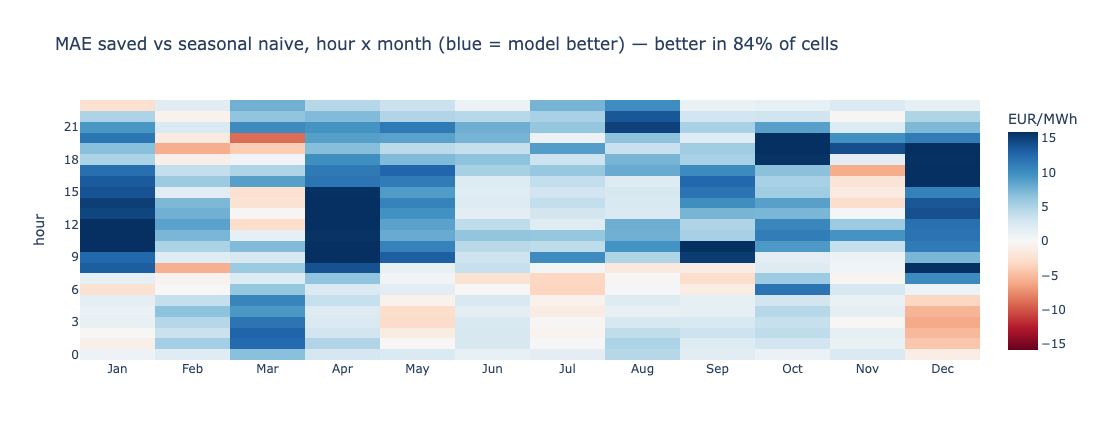

night 22-05    MAE  naive  18.4  ->  model  15.8
solar 09-16    MAE  naive  34.3  ->  model  26.4
evening 17-21  MAE  naive  38.5  ->  model  31.2
price > 200    MAE  naive  64.0  ->  model  53.1
model MAE by hour: best 14.2 at 02:00, worst 39.0 at 20:00


In [10]:
gain = (err["Seasonal naive"] - err[best])
surface = gain.groupby([test.index.hour, test.index.month]).mean().unstack()[MONTH_ORDER]
lim = float(np.nanpercentile(np.abs(surface), 95))

fig = go.Figure(go.Heatmap(z=surface.round(1), x=[calendar.month_abbr[m] for m in MONTH_ORDER],
                           y=surface.index, colorscale=DIV, zmid=0, zmin=-lim, zmax=lim,
                           colorbar=dict(title="EUR/MWh"),
                           hovertemplate="%{x} %{y:02d}:00 — naive MAE minus model MAE %{z}<extra></extra>"))
fig.update_layout(height=440, yaxis=dict(title="hour", dtick=3),
                  title=f"MAE saved vs seasonal naive, hour x month (blue = model better) — "
                        f"better in {100 * (surface > 0).to_numpy().mean():.0f}% of cells")
fig.show()
save(fig, "model_3_win_heatmap")

h = test.index.hour
for name, sel in {"night 22-05": (h >= 22) | (h <= 5), "solar 09-16": (h >= 9) & (h <= 16),
                  "evening 17-21": (h >= 17) & (h <= 21), "price > 200": (y > 200).to_numpy()}.items():
    print(f"{name:14s} MAE  naive {err['Seasonal naive'][sel].mean():5.1f}  ->  model {err[best][sel].mean():5.1f}")
eh = err.groupby(h)[best].mean()
print(f"model MAE by hour: best {eh.min():.1f} at {eh.idxmin():02d}:00, worst {eh.max():.1f} at {eh.idxmax():02d}:00")

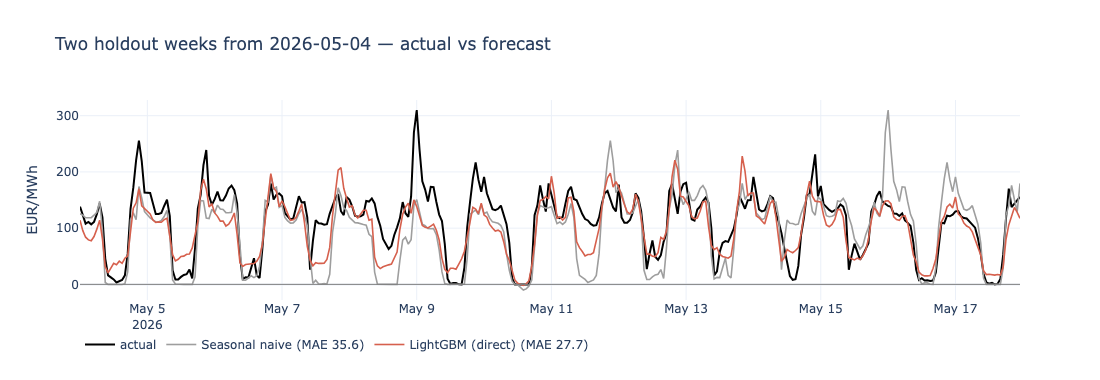

In [11]:
WEEK_FROM = "2026-05-04"
w = test.index[(test.index >= WEEK_FROM) & (test.index < pd.Timestamp(WEEK_FROM, tz=config.TZ) + pd.Timedelta(days=14))]
fig = go.Figure()
fig.add_scatter(x=w.tz_localize(None), y=y.loc[w].round(1), name="actual", line=dict(color="black", width=2))
for name, colour in [("Seasonal naive", "#9e9e9e"), (best, "#d6604d")]:
    s = pd.Series(preds[name], index=test.index).loc[w]
    fig.add_scatter(x=w.tz_localize(None), y=s.round(1), line=dict(color=colour, width=1.6),
                    name=f"{name} (MAE {np.abs(s - y.loc[w]).mean():.1f})")
fig.add_hline(y=0, line=dict(color="grey", width=1))
fig.update_layout(height=380, yaxis_title="EUR/MWh", legend=dict(orientation="h", y=-0.15),
                  title=f"Two holdout weeks from {WEEK_FROM} — actual vs forecast")
fig.show()
save(fig, "model_4_two_weeks")

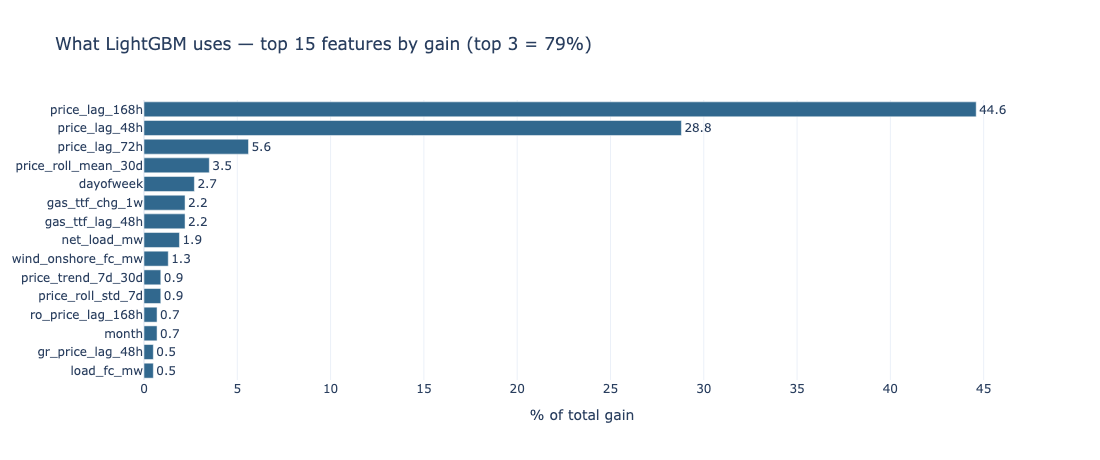

In [12]:
imp = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"), index=TREE)
imp = (imp / imp.sum() * 100).sort_values().tail(15)

fig = go.Figure(go.Bar(x=imp.round(1), y=imp.index, orientation="h", marker_color="#31688e",
                       text=imp.round(1), textposition="outside"))
fig.update_layout(height=460, xaxis_title="% of total gain",
                  title=f"What LightGBM uses — top 15 features by gain (top 3 = {imp.tail(3).sum():.0f}%)")
fig.show()
save(fig, "model_5_feature_importance")

### Understanding the model

1. **Gains sit in the solar band and the evening**: the model is better in 84 % of hour × month cells, most of all at 09–16 h — where the collapse to zero moves week to week.
2. **The evening peak stays hardest**: MAE 39 at 20:00 against 14 at 02:00; hours above 200 EUR/MWh still miss by ~53.
3. **Still mostly a lag model**: price 168 / 48 / 72 h lags carry 79 % of the gain; the day-ahead drivers add little on top — the first thing v1 should work on.
4. **Spikes are under-called**: in the two May weeks the ~300 peaks are forecast near 200 — trees average, they do not extrapolate.

## LSTM comparison (optional)

A recurrent net reading the last 168 h of the same features, same split, same holdout — to test whether
sequence modelling beats trees here. Huber loss so a few spike hours don't dominate the gradient.

In [13]:
try:
    import tensorflow as tf
except ImportError:
    tf = None

if not RUN_LSTM or tf is None:
    print("LSTM skipped — set RUN_LSTM = True and  pip install -r requirements-lstm.txt  to run it.")
else:
    from tensorflow.keras import callbacks, layers, models
    tf.random.set_seed(42); np.random.seed(42)

    LOOKBACK, STRIDE = 168, 4                  # a week of context; train on every 4th window
    split = len(train)
    med = train[LINEAR].median()
    sx = StandardScaler().fit(train[LINEAR].fillna(med))
    sy = StandardScaler().fit(train[[TARGET]])
    X = sx.transform(mdf[LINEAR].fillna(med)).astype("float32")
    r = sy.transform(mdf[[TARGET]]).ravel().astype("float32")
    seqs = lambda rows: np.stack([X[i - LOOKBACK:i] for i in rows])
    tr_rows, te_rows = np.arange(LOOKBACK, split, STRIDE), np.arange(split, len(mdf))

    net = models.Sequential([layers.Input((LOOKBACK, len(LINEAR))), layers.LSTM(64),
                             layers.Dropout(0.2), layers.Dense(1)])
    net.compile(optimizer="adam", loss=tf.keras.losses.Huber(delta=1.0))
    net.fit(seqs(tr_rows), r[tr_rows], validation_split=0.1, epochs=25, batch_size=512,
            callbacks=[callbacks.EarlyStopping(patience=4, restore_best_weights=True)], verbose=0)
    preds["LSTM"] = sy.inverse_transform(net.predict(seqs(te_rows), verbose=0)).ravel()
    scores = model.scoreboard([model.evaluate(k, y, v) for k, v in preds.items()])
    print(scores.sort_values("MAE").to_string())

                       MAE   RMSE  sMAPE_%
model                                     
LightGBM (direct)    23.32  33.01    36.66
Ridge (residual)     25.24  34.69    40.77
Ridge (direct)       25.24  34.69    40.77
LightGBM (residual)  27.20  36.57    40.05
LSTM                 27.46  36.60    40.49
Seasonal naive       28.57  42.97    44.31


## The production model

[`forecast.py train`](../forecast.py) fits the same features and parameters (`TARGET_MODE = "direct"`) on
all hours and saves them to `models/`. Its holdout score must match the scoreboard above:

In [14]:
meta = json.loads(config.META_FILE.read_text())
shipped = {m["model"]: round(m["MAE"], 2) for m in meta["holdout"]["metrics"]}
print(f"models/meta.json  trained {meta['trained_at']} on {meta['data_from']} -> {meta['data_to']}")
print(f"holdout MAE  shipped {shipped['LightGBM']}   |   this notebook {scores.loc[best, 'MAE']:.2f}")
assert abs(shipped["LightGBM"] - scores.loc[best, "MAE"]) < 0.05, "retrain: python forecast.py train"

models/meta.json  trained 2026-09-22T13:42:14 on 2017-02-02 -> 2026-09-21
holdout MAE  shipped 23.32   |   this notebook 23.32


### Next

1. **The v1 list from [01_exploration](01_exploration.ipynb)**: hour × month interactions, a price ≤ 0 collapse classifier (classify-then-regress), temperature within hour blocks.
2. **Make the drivers count**: solar forecast × hour, residual load at the evening ramp, more than one weather point.
3. **Live**: [`python forecast.py predict`](../forecast.py) runs this model on today's data; a daily cron (Raspberry Pi) and a Blynk dashboard come next.